Loading Datasets...
Admissions loaded: (275, 16)
Time-Series loaded: (5568, 16)
Survival Rate: 94.55%
Mortality Rate: 5.45%


C:\Users\saipr\AppData\Local\Temp\ipykernel_6008\1933913506.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='mortality', data=mortality_labels, palette='coolwarm')


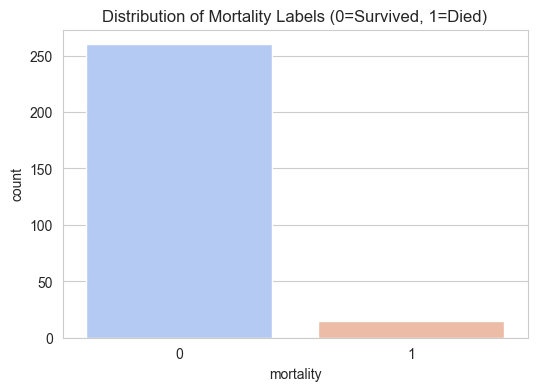


Alignment Complete.
x Shape: (232, 24, 14) (Patients, Hours, Features)
y Shape: (232,) (Labels)

Sample (Index 0) - Patient ID: 20044587.0
Label: 0 (Survived)
First 3 hours of data:
[[  1.50482903 147.33064516   1.4          4.13113232 137.38455579
    7.37        87.43334364   0.           0.           0.
    0.           0.           0.           0.        ]
 [  1.50482903 147.33064516   2.7          4.13113232 137.38455579
    7.4         87.43334364   0.           0.           0.
    0.           0.           0.           0.        ]
 [  1.50482903 147.33064516   1.8          4.13113232 137.38455579
    7.45        87.43334364   0.           0.           0.
    0.           0.           0.           0.        ]]
SUCCESS. Saved 'x_final.npy', 'y_final.npy', and 'patient_ids_final.npy' to C:\AINutriCare\Data\Transformed


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (6, 4)

# Path Configuration
raw_dir = r"C:\AINutriCare\Data\Raw"
processed_dir = r"C:\AINutriCare\Data\Transformed"

def get_raw_path(filename):
    return os.path.join(raw_dir, filename)

def get_processed_path(filename):
    return os.path.join(processed_dir, filename)

try:
    print("Loading Datasets...")
    admissions = pd.read_csv(get_raw_path('admissions.csv'))
    final_ts_df = pd.read_csv(get_processed_path('final_dynamic_icu_dataset.csv'))

    print(f"Admissions loaded: {admissions.shape}")
    print(f"Time-Series loaded: {final_ts_df.shape}")

    # --- Extract Mortality Labels ---
    mortality_labels = admissions[['hadm_id', 'hospital_expire_flag']].copy()
    mortality_labels.rename(columns={'hospital_expire_flag': 'mortality'}, inplace=True)

    # --- Check Distribution ---
    dist = mortality_labels['mortality'].value_counts(normalize=True) * 100
    print(f"Survival Rate: {dist[0]:.2f}%")
    print(f"Mortality Rate: {dist[1]:.2f}%")

    sns.countplot(x='mortality', data=mortality_labels, palette='coolwarm')
    plt.title('Distribution of Mortality Labels (0=Survived, 1=Died)')
    plt.show()

    # --- Align x (Features) and y (Labels) ---
    unique_stays = final_ts_df['hadm_id'].unique()
    aligned_labels = mortality_labels[mortality_labels['hadm_id'].isin(unique_stays)]
    label_map = aligned_labels.set_index('hadm_id')['mortality']

    x_list = []
    y_list = []
    valid_ids = []

    # Iterate through patients to ensure x[i] matches y[i] exactly
    for stay_id, group in final_ts_df.groupby('hadm_id'):
        if stay_id in label_map.index and len(group) == 24:
            # Drop metadata columns (ID, hour) to keep only feature values
            features = group.drop(columns=['hadm_id', 'hour_bin']).values
            x_list.append(features)
            y_list.append(label_map[stay_id])
            valid_ids.append(stay_id)

    x = np.stack(x_list)
    y = np.array(y_list)
    
    print(f"\nAlignment Complete.")
    print(f"x Shape: {x.shape} (Patients, Hours, Features)")
    print(f"y Shape: {y.shape} (Labels)")

    # --- Inspect Sample ---
    print(f"\nSample (Index 0) - Patient ID: {valid_ids[0]}")
    print(f"Label: {y[0]} ({'Expired' if y[0]==1 else 'Survived'})")
    print(f"First 3 hours of data:\n{x[0][:3]}")

    # --- Save Final Numpy Arrays to Transformed ---
    np.save(get_processed_path('x_final.npy'), x)
    np.save(get_processed_path('y_final.npy'), y)
    np.save(get_processed_path('patient_ids_final.npy'), np.array(valid_ids))

    print(f"SUCCESS. Saved 'x_final.npy', 'y_final.npy', and 'patient_ids_final.npy' to {processed_dir}")

except FileNotFoundError as e:
    print(f"Error: {e}. Check file paths.")
except KeyError as e:
    print(f"Key Error: {e}. Check if column names in CSV match expectations.")